# Variational Autoencoders

In [43]:
import os
import numpy as np

# Import the keras library
import tensorflow as tf
print(tf.__version__)
from tensorflow import keras
from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Layer,Reshape,Conv2DTranspose
from tensorflow.python.client import device_lib
from keras.layers import Multiply, Add
from keras import backend as K

from numpy import random

from matplotlib import pyplot as plt

2.21.0


In this notebook, Keras is used to build a Variational Autoencoder. The dataset for this is the MNIST dataset.

In [44]:
### HELPER FUNCTIONS
def plot_label_clusters(model, data, labels):
    # display a 2D plot of the digit classes in the latent space
    z_mean, _, _ = encoder.predict(data)
    plt.figure(figsize=(8, 6))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels)
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.show()

First we load the data from keras and inspect the shape and structure.

In [45]:
# Import data
(X_train, y_train), (_, _) = keras.datasets.mnist.load_data()
X_train.shape, y_train.shape, np.unique(y_train)

((60000, 28, 28), (60000,), array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8))

Next, we prepare the data so it can be used as an image in the form of [x_pix, y_pix, n_channels]. This way it works out of the box with convolutions as defined in many NN interfaces.

We also normalize the data between [0, 1] and convert to a Tensorflow dataset.

Finally, some representative sample images are plotted, togehter with their labels.

Before reshaping, X_train has a shape of: (60000, 28, 28)
After reshaping, X_train has a shape of: (60000, 28, 28, 1)


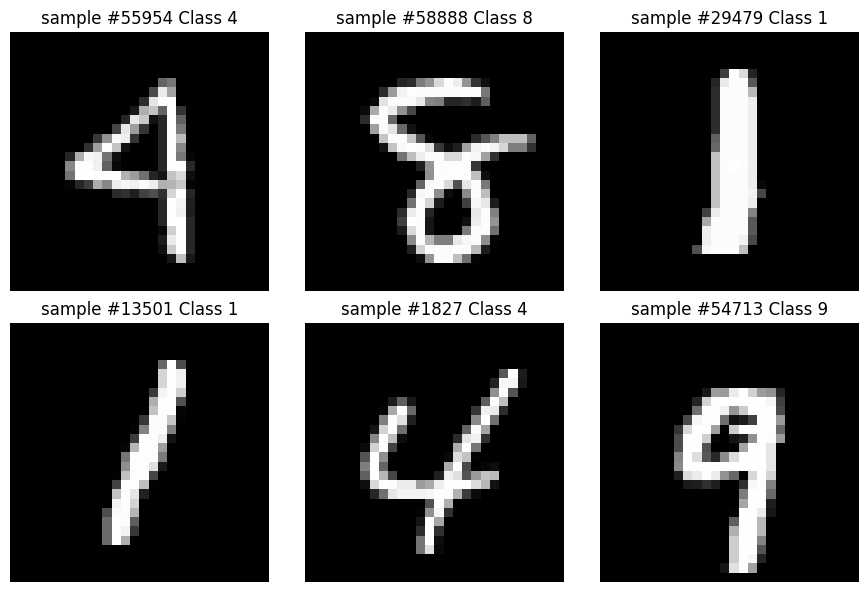

In [46]:
print(f"Before reshaping, X_train has a shape of: {X_train.shape}")

X_train = X_train.reshape((X_train.shape[0],X_train.shape[1],X_train.shape[2],1))
print(f"After reshaping, X_train has a shape of: {X_train.shape}")

X_train = tf.cast(X_train, tf.float32)
X_train = X_train/255.0

dataset = tf.data.Dataset.from_tensor_slices(X_train)

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
axes = axes.flatten()

for i, r in enumerate(random.randint(0, 59999, size=6, dtype=int)):
    axes[i].imshow(X_train[r,:,:,0], cmap="gray")
    axes[i].set_title("sample #{} Class {}".format(r, y_train[r]))
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Building the VAE model

With a standard Autoencoder, the low-dimensional latent space is a useful abstraction, but not very insightful. Since no control is being exerted on the latent space, it can be wildly different (and often unrelated) between experiments and between inputs and outputs. 

In the VAE, an additional regularisation is added to the latent space, such that the latent space follows a probability distribution (often a Gaussian with a mean and standard deviation). This way the latent space can also be used generatively since we can understand how the eventual output of the decoder arises.

The regularisation doesn't encode an input image to a single point (which increases granularity and reduced interpretability), but smears it out over the latent space by defining a mean and a standard deviation. This way the model effectively learns interpolations between the encodings instead of interpolating afterwards. This results in a much smoother generative behaviour.

### The Encoder

We start with the encoder. The first part is to define an input layer which grabs the input and performs a first level convolution. Then one or more layers can be added that reduce the dimensionality to the latent space dimension. This is actually a very important hyperparameter that significantly impacts the quality of the model.

Here we use one input layer and one hidden layer (both convolutional layers), and finally flatten into a vector as an interface to the upcoming latent space representation.

In [47]:
INPUT_SIZE = 28

# Start with the input layer (builds a symbolic tensor used for input passing)
encoder_input = keras.Input(shape=(INPUT_SIZE, INPUT_SIZE, 1))
# Apply 32 filters of size 3x3 in stride of 2. This reduces spatial dimension to 14x14
# Results in an output of shape [14,14,32]
x = Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_input)
# Apply 64 filters of size 3x3 in stride 2. Reducing spatial dimension to 7x7
# Output shape [7,7,64]
x = Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
# Flatten to a vector
# Output shape [3136,]
x = Flatten()(x)
# Project the flattened layer onto a 16-dimensional representation.
encoder_output = Dense(16, activation="relu")(x)

The next part is the latent representation. This is encoded in two dense layers that learn the mean and log variance. The reason log variance is used is that it gives more training stability. The reasoning for this is:
- The standard deviation is a non-negative real number. This would require to use a ReLU activation for this, which introduces problems at low values since the gradient is not well defined.
- The standard deviation will be a very small number since the values we are working with are generally between 0 and 1.

In [48]:
LATENT_DIM = 2

# Dense layer to learn the mean
mean = Dense(LATENT_DIM, name="mean")(encoder_output)
# Dense layer to learn the log variance
log_var = Dense(LATENT_DIM, name="z_log_var")(encoder_output)

# sigma is calculated from log variance
sigma = keras.ops.exp(0.5 * log_var)

Using these two values, we can add noise and sample a point from this distribution. This point will be used by the decoder to generate the output image (which during training should match the input passed to the encoder).

First we sample some random normal noise, use the [Reparametrization Trick](https://gregorygundersen.com/blog/2018/04/29/reparameterization/) to allow backpropagation and finally connect it to the encoder.

In [49]:
# random normal noise 
epsilon = keras.layers.Lambda(
    lambda x: tf.random.normal(shape=tf.shape(x))
)(mean)
#z = mean + sigma * epsilon 
z_eps = Multiply()([sigma, epsilon])
z = Add()([mean, z_eps])

encoder = Model(encoder_input, outputs = [mean, log_var, z], name = 'encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │     50,192 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean (Dense)        │ (None, 2)         │         34 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 2)         │          0 │ z_log_var[0][0]   │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exp_2 (Exp)         │ (None, 2)         │          0 │ multiply_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 2)         │          0 │ mean[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_7          │ (None, 2)         │          0 │ exp_2[0][0],      │
│ (Multiply)          │                   │            │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 2)         │          0 │ mean[0][0],       │
│                     │                   │            │ multiply_7[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

With that out of the way, we need to build the decoder part, which is largely the inverse of the encoder.

### Decoder

The decoder rebuilds the image from the latent representation, into a full image again. During training the goal is to reproduce the inut image as closely as possible. From the latent representation we first take in the latent representation of mean and standard deviation. Then upscale this to a vector of shape [7*7*64,] which is then recast into an image of shape [7, 7, 64]. Then the exact inverse of the downscaling in the input is performed to recover a 28x28 image.

In [50]:
latent_dim=2
decoder=Sequential()

decoder.add(keras.Input(shape=(latent_dim,))) # input dimension is 2
decoder.add(Dense(7 * 7 * 64, activation="relu"))
decoder.add(Reshape((7, 7, 64)))
decoder.add(Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same"))
decoder.add(Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same"))
decoder.add(Conv2DTranspose(1, 3, activation="sigmoid", padding="same"))
decoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

### Loss Function

Then finally we need a way to determine the quality of the training with a loss function. As alluded to before, the loss function measure the difference between the encoder input and the decoder output, this is known as the *reconstruction loss*. An additional regularization term is added, the k1_loss. This loss function rewards the network when the learned distribution is close to a standard normal distribution.

In [ ]:
#reconstruction_loss
def reconstruction_loss(y, y_hat):
    return tf.reduce_mean(tf.square(y - y_hat))

#Kullback–Leibler divergence encoder loss
def kl_loss(mu, log_var):
    return -0.5 * tf.reduce_mean(1 + log_var - tf.square(mean) - tf.exp(log_var))

# add two losses 
def vae_loss(y_true, y_hat, mu, log_var):
    return reconstruction_loss(y_true, y_hat) + (1 / (64*64)) * kl_loss(mean, log_var)

## Combining the encoder and decoder

For the full VAE architecture we have to link the encoder to the decoder. After this we can start training the full model in configuration.

In [58]:
class VAE(Model):
	def __init__(self, encoder, decoder, **kwargs):
		super().__init__(**kwargs)
		self.encoder = encoder
		self.decoder = decoder

	def train_step(self, data):
		with tf.GradientTape() as tape:
			z_mean, z_log_var, z = self.encoder(data)
			reconstruction = self.decoder(z)
			reconstruction_loss = tf.reduce_mean(tf.square(data - reconstruction))
			kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
			total_loss = reconstruction_loss + (1 / (INPUT_SIZE * INPUT_SIZE)) * kl_loss
		grads = tape.gradient(total_loss, self.trainable_weights)
		self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
		return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}
	
	def call(self, inputs):
		z_mean, z_log_var, z = self.encoder(inputs)
		reconstruction = self.decoder(z)
		kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
		self.add_loss(kl_loss)
		return reconstruction

model = VAE(encoder, decoder, name="vae")
model.compile(optimizer="adam")
model.summary()

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ [(None, 2), (None, 2), │        69,076 │
│                                 │ (None, 2)]             │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 28, 28, 1)      │        65,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,165 (524.08 KB)

 Trainable params: 134,165 (524.08 KB)

 Non-trainable params: 0 (0.00 B)

Samples generated by decoder after 0 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


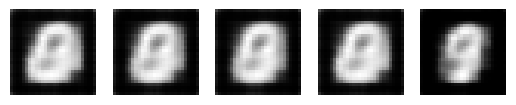

2D latent representations of the training data produced by encoder after 0 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


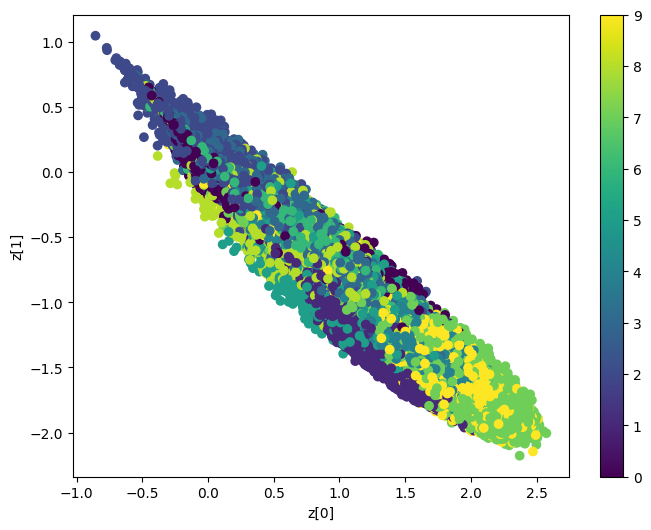

Epoch: 0 - Step: 599 - MSE loss: 0.058507405 - KL loss: 1.6049484
Samples generated by decoder after 1 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


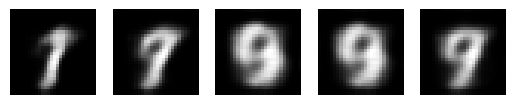

2D latent representations of the training data produced by encoder after 1 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


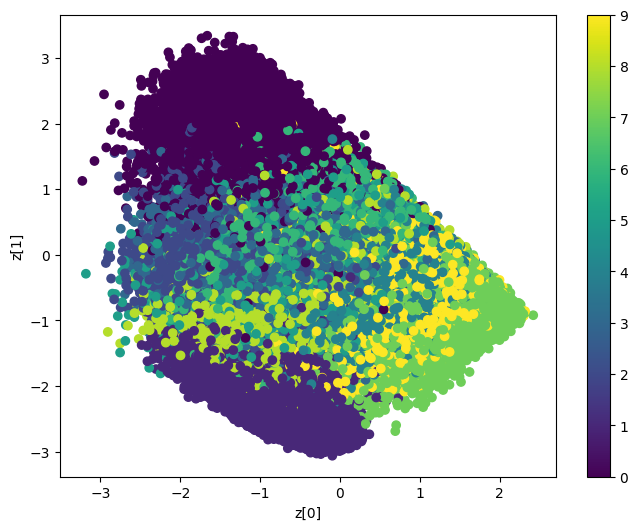

Epoch: 1 - Step: 599 - MSE loss: 0.054854598 - KL loss: 1.9594574
Samples generated by decoder after 2 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


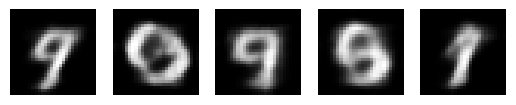

2D latent representations of the training data produced by encoder after 2 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


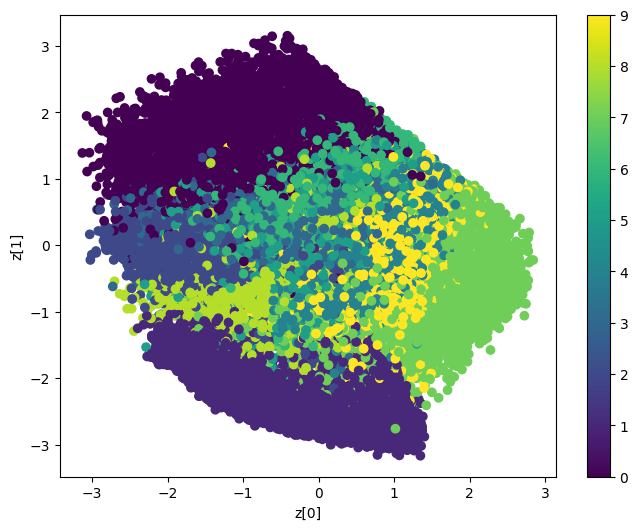

Epoch: 2 - Step: 599 - MSE loss: 0.052678235 - KL loss: 2.0552437
Samples generated by decoder after 3 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


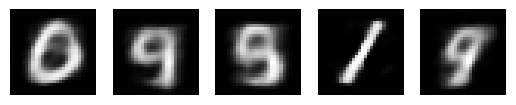

2D latent representations of the training data produced by encoder after 3 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


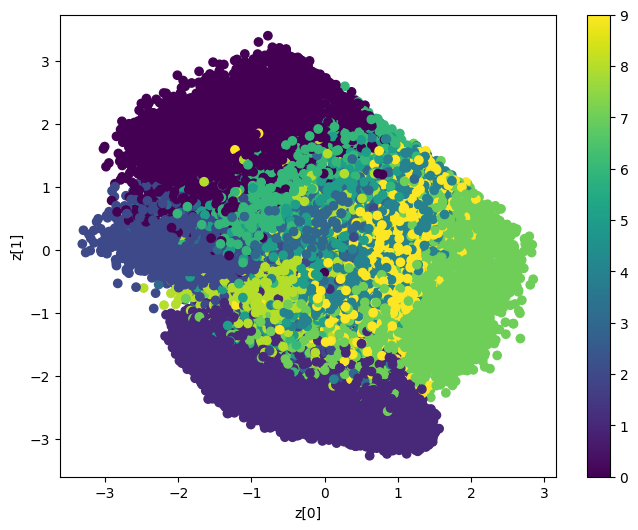

Epoch: 3 - Step: 599 - MSE loss: 0.051199548 - KL loss: 2.2661397
Samples generated by decoder after 4 epoch(s): 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


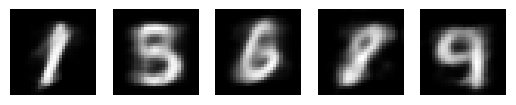

2D latent representations of the training data produced by encoder after 4 epoch(s): 
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


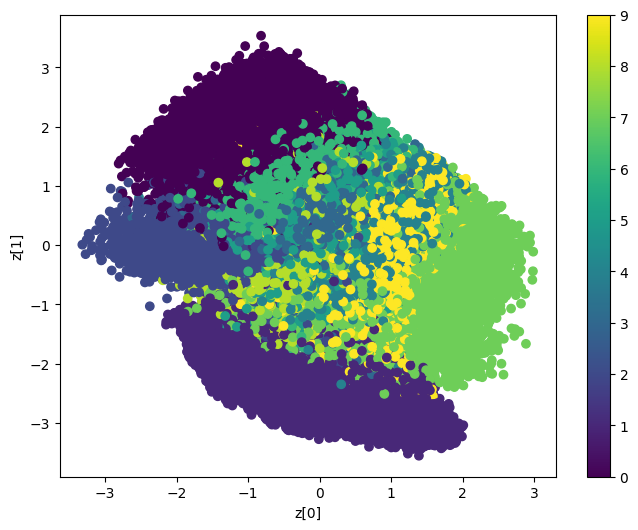

Epoch: 4 - Step: 599 - MSE loss: 0.05068612 - KL loss: 2.2926414


In [59]:
#loss
mse_losses = []
kl_losses = []
epochs = 5

for epoch in range(epochs):
    
    print(f"Samples generated by decoder after {epoch} epoch(s): ")
    
    #random noise
    z = tf.random.normal(shape = (5, latent_dim,))

    # input random noise into the decoder
    xhat = decoder.predict(z)
    
    # plot the decoder output
    plt.figure()
    for i in range(5):
        plt.subplot(1,5,i+1)
        plt.imshow(xhat[i,:,:,0],cmap="gray")
        plt.axis("off")
    plt.show()

    print(f"2D latent representations of the training data produced by encoder after {epoch} epoch(s): ")
    plot_label_clusters(encoder, X_train, y_train)

    # training steps
    for (step, training_batch) in enumerate(dataset.batch(100)):

        # Call train_step directly instead of manual gradient tape
        metrics = model.train_step(training_batch)
        
        # Extract losses from the returned metrics dict
        mse_loss = metrics["reconstruction_loss"]
        kl = metrics["kl_loss"]
        
        kl_losses.append(kl.numpy())
        mse_losses.append(mse_loss.numpy())
         
    print("Epoch: %s - Step: %s - MSE loss: %s - KL loss: %s" % (epoch, step, mse_loss.numpy(), kl.numpy()))
  

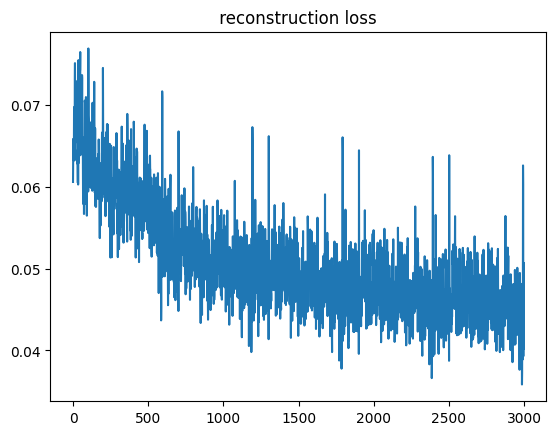

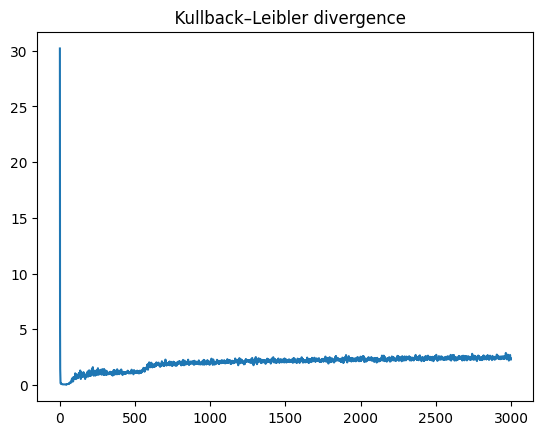

In [60]:
plt.plot(mse_losses)
plt.title(" reconstruction loss ")
plt.show()
plt.plot(kl_losses)
plt.title("  Kullback–Leibler divergence")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


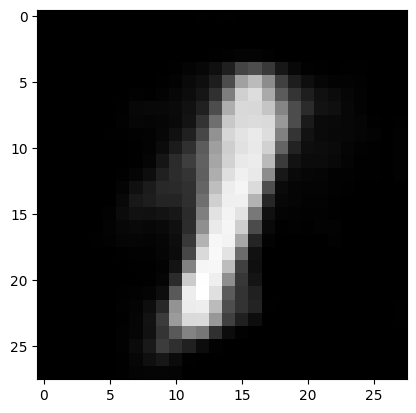

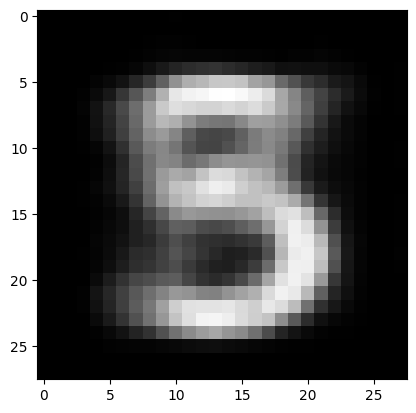

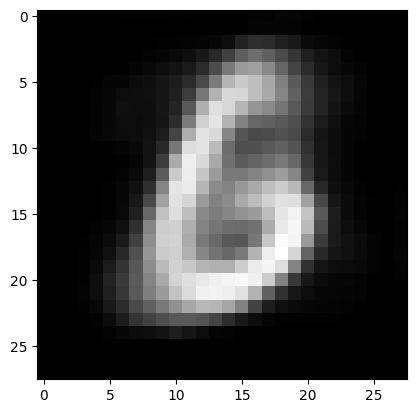

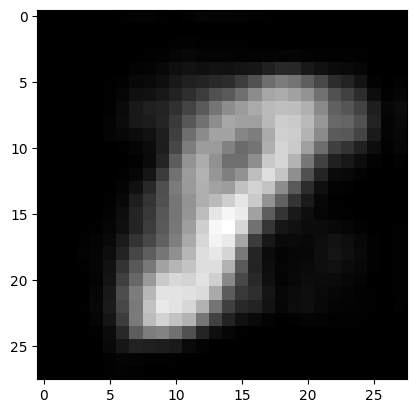

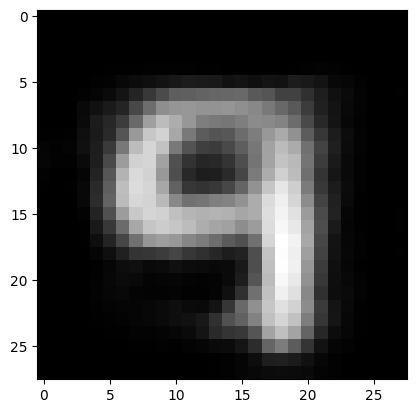

In [61]:
xhat = decoder.predict(z)

for i in range(5):
    plt.imshow(xhat[i,:,:,0],cmap="gray")
    plt.show()

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


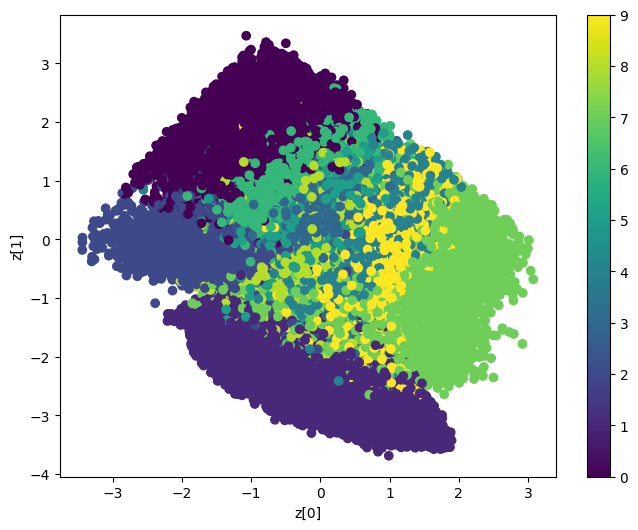

In [62]:
plot_label_clusters(encoder, X_train, y_train)